# ⚛️ VQC2024 — VARIATIONAL ENCODING (Data Re-uploading) — 8 QUBITS

## 🔴 Principe : Variational Encoding — Data Re-uploading

**Pérez-Salinas et al. (2020)** : les features sont ré-injectées dans le circuit
à **chaque couche**, intercalées avec des paramètres entraînables θ.

```
Pour chaque couche L (× N_LAYERS) :
  ① RY(xi + θ_bias_Li)  sur chaque qubit i  ← feature + biais apprenable
  ② RZ(θ_RZ_Li)         sur chaque qubit i  ← rotation de phase apprenante
  ③ CNOT ring  (qubit i → qubit (i+1) mod N)  ← entanglement
```

| Propriété | Valeur |
|---|---|
| Qubits | 8 |
| Couches | 3 |
| Paramètres apprenables | 3 × 8 × 2 = 48 (θ_bias + θ_RZ) |
| Avantage | Approximateur universel — features vues N_LAYERS fois |
| Référence | Pérez-Salinas et al., *Data re-uploading for a universal quantum classifier*, 2020 |

---

## 🗺️ Pipeline

```
embeddings_2024.pt (128d — THGNN classique figé)
    → PCA 128d → 8d + normalisation
    → VARIATIONAL ENCODING — 8 qubits
    → Loss hybride : Contrastive (k-NN self-sup) + Compacité
    → Embeddings quantiques (N × 8)
    → UMAP + HDBSCAN (params identiques au classique)
    → Comparaison classique vs quantique
```

## 📊 Baseline classique à battre
| Année | Silhouette | Davies-Bouldin | Bruit (%) | Clusters |
|-------|-----------|---------------|-----------|----------|
| 2024  | 0.346     | 0.631         | 29.0%     | 107      |

## ♻️ Reprise depuis checkpoint
1. Télécharge `vqc_variational_2024.pt` depuis l'onglet Output
2. Upload en dataset Kaggle
3. **Add Input** dans ce notebook
4. Run All → reprise automatique


In [15]:
# ============================================================
# CELLULE 1 — Installation des dépendances
# ============================================================
# pennylane         : framework quantum ML (interface PyTorch native)
# pennylane-lightning: backend CPU optimisé C++ (~5x default.qubit)
# umap-learn        : réduction dimensionnelle pour visualisation
# hdbscan           : clustering density-based

import subprocess, sys

pkgs = ["pennylane", "pennylane-lightning", "umap-learn", "hdbscan"]
for pkg in pkgs:
    print(f"📦 Installation : {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    print(f"   ✅ {pkg} installé")

print("\n✅ Toutes les dépendances installées")

📦 Installation : pennylane...
   ✅ pennylane installé
📦 Installation : pennylane-lightning...
   ✅ pennylane-lightning installé
📦 Installation : umap-learn...
   ✅ umap-learn installé
📦 Installation : hdbscan...
   ✅ hdbscan installé

✅ Toutes les dépendances installées


In [16]:
# ============================================================
# CELLULE 2 — Imports & Configuration globale
# ============================================================

import os, gc, json, time, warnings, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter

import pennylane as qml

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
import umap
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

# ── Reproductibilité ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Chemins Kaggle ────────────────────────────────────────────
OUTPUT_DIR     = "/kaggle/working/quantum_clustering"
CKPT_DIR       = os.path.join(OUTPUT_DIR, "checkpoints")

# ── Checkpoint session précédente (input Kaggle) ────────────
CKPT_DIR_INPUT = None
for _root, _dirs, _files in os.walk("/kaggle/input"):
    for _fname in _files:
        if _fname.startswith("vqc_") and _fname.endswith(".pt"):
            CKPT_DIR_INPUT = _root
            break
    if CKPT_DIR_INPUT:
        break
if CKPT_DIR_INPUT:
    print(f"♻️  Checkpoints INPUT trouvés : {CKPT_DIR_INPUT}")
else:
    print("ℹ️  Aucun checkpoint en input — démarrage from scratch")
# ── Checkpoint input (session précédente) ────────────────────
# Cherche automatiquement un checkpoint sauvegardé en input Kaggle
# (ajoute ton output précédent en "Add Input" dans le panel notebook)
CKPT_DIR_INPUT = None
for root, dirs, files in os.walk("/kaggle/input"):
    for fname in files:
        if fname.startswith("vqc_") and fname.endswith(".pt"):
            CKPT_DIR_INPUT = root
            break
    if CKPT_DIR_INPUT:
        break

if CKPT_DIR_INPUT:
    print(f"♻️  Checkpoints trouvés en INPUT : {CKPT_DIR_INPUT}")
else:
    print(f"ℹ️  Aucun checkpoint en input — démarrage from scratch")
    
CLUSTER_OUT    = os.path.join(OUTPUT_DIR, "clustering")
for d in [OUTPUT_DIR, CKPT_DIR, CLUSTER_OUT]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Hyperparamètres VQC ───────────────────────────────────────
N_QUBITS       = 8       # 8 qubits = 2^8=256 états
N_LAYERS       = 3       # couches variationnelles → 3×8×3 = 72 paramètres
PCA_DIM        = 8       # = N_QUBITS
BATCH_SIZE_Q   = 4098   # batch VQC : petit pour économiser RAM
N_EPOCHS_VQC   = 40      # epochs entraînement
LR_VQC         = 5e-3    # learning rate Adam (plus élevé car circuit petit)
K_NN           = 15      # voisins pour paires positives contrastive
LAMBDA_COMPACT = 0.4     # poids loss compacité
MARGIN         = 1.0     # marge hinge loss contrastive
TRAIN_SUBSAMPLE = 20_000 # sous-échantillonnage entraînement VQC
INFER_SUBSAMPLE = 30_000 # sous-échantillonnage inférence → propagation k-NN

# ── Hyperparamètres HDBSCAN (IDENTIQUES au classique) ────────
# ⚠️  NE PAS MODIFIER — comparaison équitable avec la baseline
MIN_CLUSTER_SIZE = 300
MIN_SAMPLES      = 30
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST    = 0.05
UMAP_METRIC      = "cosine"

# ── Encodings à tester ────────────────────────────────────────
ENCODINGS = ["variational"]    # variational encoding uniquement

# ── Baseline classique (pour comparaison finale) ──────────────
BASELINE = {
    2024: {"silhouette": 0.346, "davies_bouldin": 0.631,
           "noise_pct": 29.0,  "n_clusters": 107,
           "calinski_harabasz": 61670.0},
    2025: {"silhouette": 0.434, "davies_bouldin": 0.700,
           "noise_pct": 41.0,  "n_clusters": 66,
           "calinski_harabasz": 66597.0},
}

print("=" * 60)
print("⚛️  QUANTUM CLUSTERING — Configuration")
print("=" * 60)
print(f"  Device          : {DEVICE}")
print(f"  N_QUBITS        : {N_QUBITS}  (2^{N_QUBITS} = {2**N_QUBITS} états)")
print(f"  N_LAYERS        : {N_LAYERS}  → {N_LAYERS*N_QUBITS*3} paramètres VQC")
print(f"  PCA_DIM         : {PCA_DIM}")
print(f"  Encodings       : {ENCODINGS}")
print(f"  Epochs VQC      : {N_EPOCHS_VQC}")
print(f"  Batch size VQC  : {BATCH_SIZE_Q}")
print(f"  Train subsample : {TRAIN_SUBSAMPLE:,}")
print(f"  Infer subsample : {INFER_SUBSAMPLE:,}")
print()
print(f"  HDBSCAN (figés, identiques au classique) :")
print(f"    min_cluster_size = {MIN_CLUSTER_SIZE}")
print(f"    min_samples      = {MIN_SAMPLES}")
print(f"    umap_n_neighbors = {UMAP_N_NEIGHBORS}")
print(f"    umap_metric      = {UMAP_METRIC}")
print()
print(f"  Output dir      : {OUTPUT_DIR}")
print(f"  Checkpoints     : {CKPT_DIR}")
print("=" * 60)

ℹ️  Aucun checkpoint en input — démarrage from scratch
ℹ️  Aucun checkpoint en input — démarrage from scratch
⚛️  QUANTUM CLUSTERING — Configuration
  Device          : cpu
  N_QUBITS        : 8  (2^8 = 256 états)
  N_LAYERS        : 3  → 72 paramètres VQC
  PCA_DIM         : 8
  Encodings       : ['variational']
  Epochs VQC      : 40
  Batch size VQC  : 4098
  Train subsample : 20,000
  Infer subsample : 30,000

  HDBSCAN (figés, identiques au classique) :
    min_cluster_size = 300
    min_samples      = 30
    umap_n_neighbors = 15
    umap_metric      = cosine

  Output dir      : /kaggle/working/quantum_clustering
  Checkpoints     : /kaggle/working/quantum_clustering/checkpoints


In [17]:
# ============================================================
# CELLULE 3 — Chargement des embeddings classiques THGNN
# ============================================================
# Structure attendue de embeddings_{year}.pt (produit par cellule 8 classique) :
#   {
#     "embeddings" : Tensor (N, 128)  ← embeddings bruts L2-normalisés
#     "node_ids"   : Tensor (N,)      ← IDs originaux auteurs
#     "global_idx" : Tensor (N,)      ← indices state bank
#     "year"       : int
#     "hidden_dim" : int (= 128)
#   }
# On extrait uniquement embeddings + node_ids.
# Le modèle THGNN n'est PAS chargé — on travaille uniquement sur les tenseurs figés.

def find_embedding_path(year):
    """Trouve automatiquement embeddings_{year}.pt dans /kaggle/input/ (tous sous-dossiers)."""
    fname = f"embeddings_{year}.pt"
    for root, dirs, files in os.walk("/kaggle/input"):
        if fname in files:
            return os.path.join(root, fname)
    raise FileNotFoundError(
        f"❌ {fname} introuvable dans /kaggle/input/\n"
        f"   Vérifie que le dataset 'classic train output' est bien ajouté en input."
    )

raw_embeddings = {}   # { year: np.array (N, 128) float32 }
node_ids_dict  = {}   # { year: np.array (N,)      int64  }

print("=" * 60)
print("📦 CHARGEMENT EMBEDDINGS CLASSIQUES")
print("=" * 60)

for year in [2024]:  # 2024 uniquement
    path = find_embedding_path(year)
    print(f"\n  Année {year}")
    print(f"  Chemin : {path}")

    d   = torch.load(path, map_location="cpu", weights_only=False)
    emb = d["embeddings"].float().numpy()     # (N, 128)
    ids = d["node_ids"].numpy().astype(np.int64)  # (N,)

    raw_embeddings[year] = emb
    node_ids_dict[year]  = ids

    # Statistiques
    norms = np.linalg.norm(emb, axis=1)
    print(f"  Shape       : {emb.shape}")
    print(f"  Dtype       : {emb.dtype}")
    print(f"  N auteurs   : {emb.shape[0]:,}")
    print(f"  Norme L2    : mean={norms.mean():.4f}  std={norms.std():.4f}")
    print(f"  Valeurs     : min={emb.min():.4f}  max={emb.max():.4f}")

print("\n" + "=" * 60)
print("✅ Embeddings chargés — modèle THGNN NE SERA PAS retouché")
print("   Toute la suite opère uniquement sur ces tenseurs figés.")
print("=" * 60)

📦 CHARGEMENT EMBEDDINGS CLASSIQUES

  Année 2024
  Chemin : /kaggle/input/datasets/arokkh/output-classique/embeddings_2024.pt
  Shape       : (246113, 128)
  Dtype       : float32
  N auteurs   : 246,113
  Norme L2    : mean=1.0000  std=0.0000
  Valeurs     : min=-0.3376  max=0.3513

✅ Embeddings chargés — modèle THGNN NE SERA PAS retouché
   Toute la suite opère uniquement sur ces tenseurs figés.


In [18]:
# ============================================================
# CELLULE 4 — PCA 128 → 8 dims + normalisation [0, π]
# ============================================================
# Pourquoi PCA avant encodage quantique ?
#   → Un circuit à N qubits encode exactement N features.
#   → 128 features nécessiterait 128 qubits = irréaliste en simulation.
#   → 8 qubits = compromis optimal : rapide + ~75% variance conservée.
#
# Normalisation [0, π] :
#   → Angle encoding : RY(θ) avec θ ∈ [0, π] couvre la sphère de Bloch complète.
#   → Phase encoding : RZ(φ) idem.
#   → Amplitude encoding : normalisation L2 séparée (cf. cellule encodages).
#
# ⚠️  Chaque année a son propre StandardScaler + PCA.
#     Pas de fuite inter-années.

pca_embeddings = {}   # { year: np.array (N, 8) float32  dans [0, π] }
pca_objects    = {}   # { year: PCA }  pour traçabilité variance expliquée
scaler_objects = {}   # { year: StandardScaler }

print("=" * 60)
print("📐 PCA 128 → 8 dims + normalisation [0, π]")
print("=" * 60)

for year in [2024]:  # 2024 uniquement
    emb = raw_embeddings[year]   # (N, 128)
    N   = emb.shape[0]
    print(f"\n  Année {year}  ({N:,} auteurs)")

    # ── Étape 1 : StandardScaler ─────────────────────────────
    scaler     = StandardScaler()
    emb_scaled = scaler.fit_transform(emb)   # (N, 128)
    print(f"  [1/3] StandardScaler → mean≈0, std≈1")

    # ── Étape 2 : PCA → 8 composantes ───────────────────────
    pca      = PCA(n_components=PCA_DIM, random_state=SEED)
    emb_pca  = pca.fit_transform(emb_scaled)   # (N, 8)
    var_ratio = pca.explained_variance_ratio_.sum() * 100
    print(f"  [2/3] PCA {emb.shape[1]}d → {PCA_DIM}d  "
          f"| variance expliquée : {var_ratio:.2f}%")
    print(f"         variance par composante : "
          f"{[f'{v*100:.1f}%' for v in pca.explained_variance_ratio_]}")

    # ── Étape 3 : Normalisation [0, π] ──────────────────────
    emb_min  = emb_pca.min(axis=0, keepdims=True)
    emb_max  = emb_pca.max(axis=0, keepdims=True)
    emb_norm = (emb_pca - emb_min) / (emb_max - emb_min + 1e-9) * np.pi
    print(f"  [3/3] Normalisation → [0, π]  "
          f"min={emb_norm.min():.4f}  max={emb_norm.max():.4f}")

    pca_embeddings[year] = emb_norm.astype(np.float32)
    pca_objects[year]    = pca
    scaler_objects[year] = scaler

    print(f"  ✅ Shape finale : {pca_embeddings[year].shape}")

print("\n" + "=" * 60)
print("✅ PCA terminé — embeddings prêts pour encodage quantique")
print("=" * 60)

📐 PCA 128 → 8 dims + normalisation [0, π]

  Année 2024  (246,113 auteurs)
  [1/3] StandardScaler → mean≈0, std≈1
  [2/3] PCA 128d → 8d  | variance expliquée : 33.08%
         variance par composante : ['6.5%', '5.7%', '4.3%', '3.7%', '3.6%', '3.3%', '3.1%', '2.9%']
  [3/3] Normalisation → [0, π]  min=0.0000  max=3.1416
  ✅ Shape finale : (246113, 8)

✅ PCA terminé — embeddings prêts pour encodage quantique


In [19]:
# ============================================================
# CELLULE 5 — Variational Encoding (Data Re-uploading)
# ============================================================
# Pérez-Salinas et al. (2020) : les features sont ré-injectées
# à chaque couche, intercalées avec des paramètres apprenables.
#
# Structure par couche :
#   ① RY(xi + θ_bias) sur qubit i  ← feature + biais apprenable
#   ② RZ(θ_RZ)        sur qubit i  ← rotation de phase apprenante
#   ③ CNOT ring                     ← entanglement entre voisins

WIRES = list(range(N_QUBITS))


def variational_encoding(x, wires, weights_enc):
    """
    Data Re-uploading Variational Encoding.

    x           : tensor (N_QUBITS,) dans [0, π]
    wires       : list[int]
    weights_enc : tensor (N_LAYERS, N_QUBITS, 2)
                  [:, :, 0] = θ_bias (biais RY apprenable)
                  [:, :, 1] = θ_RZ   (rotation de phase apprenante)
    """
    n_layers_enc = weights_enc.shape[0]
    for layer in range(n_layers_enc):
        for i, wire in enumerate(wires):
            qml.RY(x[i] + weights_enc[layer, i, 0], wires=wire)
            qml.RZ(weights_enc[layer, i, 1], wires=wire)
        for i in range(len(wires)):
            qml.CNOT(wires=[wires[i], wires[(i + 1) % len(wires)]])


ENCODING_FN = {
    "variational": variational_encoding,
}

print("=" * 60)
print("⚛️  VARIATIONAL ENCODING (Data Re-uploading)")
print("=" * 60)
print(f"  Principe : RY(xi+θ_bias) · RZ(θ) + CNOT ring × {N_LAYERS} couches")
print(f"  N_QUBITS : {N_QUBITS}")
print(f"  N_LAYERS : {N_LAYERS}")
print(f"  Params   : {N_LAYERS} × {N_QUBITS} × 2 = {N_LAYERS*N_QUBITS*2}")
print(f"  Wires    : {WIRES}")
print("=" * 60)


⚛️  VARIATIONAL ENCODING (Data Re-uploading)
  Principe : RY(xi+θ_bias) · RZ(θ) + CNOT ring × 3 couches
  N_QUBITS : 8
  N_LAYERS : 3
  Params   : 3 × 8 × 2 = 48
  Wires    : [0, 1, 2, 3, 4, 5, 6, 7]


In [20]:
# ============================================================
# CELLULE 6 — Architecture VQC + QuantumEmbeddingModel
# ============================================================
# Structure du circuit pour chaque sample x :
#
#   [Encodage(x)]  →  [StronglyEntanglingLayers(weights)]  →  [⟨Z_i⟩ pour i=0..7]
#
# StronglyEntanglingLayers :
#   → Rotations Rx, Ry, Rz paramétrées sur chaque qubit
#   → Entanglement CNOT sur toutes les paires (couverture complète)
#   → N_LAYERS couches empilées
#   → N_params = N_LAYERS × N_QUBITS × 3 = 3 × 8 × 3 = 72 paramètres
#
# Sortie : vecteur (N_QUBITS,) ∈ [-1, 1]^8 (expectation values ⟨PauliZ⟩)
#
# QuantumEmbeddingModel :
#   QuantumLayer → LayerNorm → Linear(8,8) → L2-normalisation
#   La couche linéaire post-circuit est classique et rapide.

# ── Backend PennyLane ────────────────────────────────────────
try:
    dev = qml.device("lightning.qubit", wires=N_QUBITS)
    BACKEND = "lightning.qubit"
    print(f"✅ Backend : lightning.qubit (C++ optimisé — recommandé)")
except Exception as e:
    dev = qml.device("default.qubit", wires=N_QUBITS)
    BACKEND = "default.qubit"
    print(f"⚠️  Backend : default.qubit (lightning non disponible : {e})")


def build_vqc_circuit(encoding_name):
    """
    Construit un QNode PennyLane différentiable (interface PyTorch).
    Retourne circuit(x, weights) → list[ExpectationValue] de taille N_QUBITS.
    """
    enc_fn = ENCODING_FN[encoding_name]

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(x, weights_enc):
        # ── Variational Encoding : data re-uploading ─────────
        # weights_enc shape : (N_LAYERS, N_QUBITS, 2)
        enc_fn(x, WIRES, weights_enc)
        # ── Mesure : expectation value PauliZ par qubit ──────
        return [qml.expval(qml.PauliZ(i)) for i in WIRES]

    return circuit


class QuantumLayer(nn.Module):
    """
    Couche quantique PyTorch.
    Forward : (B, PCA_DIM) → (B, N_QUBITS)
    Traite chaque sample séquentiellement (PennyLane CPU).
    """

    def __init__(self, encoding_name):
        super().__init__()
        self.encoding_name = encoding_name
        # Poids apprenables : (N_LAYERS, N_QUBITS, 2) — θ_bias + θ_RZ
        w_shape      = (N_LAYERS, N_QUBITS, 2)
        init_weights = (torch.rand(w_shape) * 2 * torch.tensor(np.pi)).float()
        self.weights = nn.Parameter(init_weights)
        self.circuit = build_vqc_circuit(encoding_name)
        self.n_params = N_LAYERS * N_QUBITS * 2

    def forward(self, x):
        """
        x : (B, PCA_DIM) float32
        → (B, N_QUBITS)  float32
        """
        outputs = []
        for i in range(x.shape[0]):
            out = self.circuit(x[i], self.weights)   # weights = weights_enc (N_LAYERS, N_QUBITS, 2)
            outputs.append(torch.stack(out))          # (N_QUBITS,)
        return torch.stack(outputs)   # (B, N_QUBITS)


class QuantumEmbeddingModel(nn.Module):
    """
    Modèle complet : QuantumLayer + post-traitement classique.

    Pipeline :
      (B, 8) → QuantumLayer → (B, 8) → LayerNorm → Linear(8,8) → L2-norm → (B, 8)

    La couche linéaire post-circuit permet une transformation supplémentaire
    apprenante dans l'espace de sortie (classique, quasi-instantanée).
    """

    def __init__(self, encoding_name):
        super().__init__()
        self.encoding_name = encoding_name
        self.q_layer       = QuantumLayer(encoding_name)
        self.norm          = nn.LayerNorm(N_QUBITS)
        self.proj          = nn.Linear(N_QUBITS, N_QUBITS)

    def forward(self, x):
        z = self.q_layer(x)       # (B, 8)  valeurs ∈ [-1, 1]
        z = self.norm(z)           # normalisation interne
        z = self.proj(z)           # projection apprenante
        return F.normalize(z, dim=-1)   # L2-normalisation finale


# ── Test rapide du circuit ────────────────────────────────────
print("=" * 60)
print("⚛️  ARCHITECTURE VQC — Test de smoke")
print("=" * 60)
print(f"  Backend        : {BACKEND}")
print(f"  N_QUBITS       : {N_QUBITS}")
print(f"  N_LAYERS       : {N_LAYERS}")
print(f"  N_params VQC   : {N_LAYERS * N_QUBITS * 2}  (θ_bias + θ_RZ par qubit par couche)")
print()

for enc in ENCODINGS:
    print(f"  Test {enc}...")
    try:
        t0    = time.time()
        model_test = QuantumEmbeddingModel(enc)
        x_test     = torch.rand(2, PCA_DIM) * np.pi   # 2 samples de test
        out_test   = model_test(x_test)
        dt         = time.time() - t0
        total_p    = sum(p.numel() for p in model_test.parameters())
        print(f"    ✅ OK | output shape={out_test.shape} | "
              f"total params={total_p} | temps 2 samples={dt:.2f}s")
        del model_test, x_test, out_test
    except Exception as e:
        print(f"    ❌ ERREUR : {e}")

print()
print(f"  Estimation temps/epoch (TRAIN_SUBSAMPLE={TRAIN_SUBSAMPLE:,}) :")
n_batches_est = TRAIN_SUBSAMPLE // BATCH_SIZE_Q
# Mesure sur 1 batch
model_tmp  = QuantumEmbeddingModel("variational")
x_tmp      = torch.rand(BATCH_SIZE_Q, PCA_DIM) * np.pi
t0         = time.time()
_          = model_tmp(x_tmp)
t_batch    = time.time() - t0
t_epoch_est = t_batch * n_batches_est
t_total_est = t_epoch_est * N_EPOCHS_VQC * len(ENCODINGS) * 2   # × 2 années
del model_tmp, x_tmp
print(f"    Temps / batch ({BATCH_SIZE_Q} samples) : {t_batch:.2f}s")
print(f"    Temps / epoch ({n_batches_est} batches) : {t_epoch_est/60:.1f} min")
print(f"    Temps total estimé ({N_EPOCHS_VQC} epochs × {len(ENCODINGS)} enc × 2 ans) : "
      f"{t_total_est/3600:.1f}h")
print("=" * 60)

✅ Backend : lightning.qubit (C++ optimisé — recommandé)
⚛️  ARCHITECTURE VQC — Test de smoke
  Backend        : lightning.qubit
  N_QUBITS       : 8
  N_LAYERS       : 3
  N_params VQC   : 48  (θ_bias + θ_RZ par qubit par couche)

  Test variational...
    ✅ OK | output shape=torch.Size([2, 8]) | total params=136 | temps 2 samples=0.05s

  Estimation temps/epoch (TRAIN_SUBSAMPLE=20,000) :
    Temps / batch (4098 samples) : 47.10s
    Temps / epoch (4 batches) : 3.1 min
    Temps total estimé (40 epochs × 1 enc × 2 ans) : 4.2h


In [21]:
# ============================================================
# CELLULE 7 — Loss hybride : Contrastive k-NN + Compacité
# ============================================================
# Pourquoi self-supervised et pas pseudo-labels HDBSCAN ?
#   → Les labels classiques ont 41% bruit (2025) : utiliser ces labels
#     directement biaiserait le VQC vers la même structure bruitée.
#   → Approche self-supervised : paires construites à partir
#     de la géométrie k-NN dans l'espace PCA original.
#     Hypothèse : les voisins proches en 8D PCA = même communauté thématique.
#
# ① LOSS CONTRASTIVE (Margin Contrastive)
#   Paires positives  : k voisins k-NN dans l'espace PCA (voisins thématiques)
#   Paires négatives  : non-voisins aléatoires
#   L_contr = mean(d_pos) + mean(max(0, margin - d_neg))
#
# ② LOSS COMPACITÉ (Variance intra-batch)
#   L_compact = mean(||z_i - z_mean||²)
#   Force les représentations à rester groupées → évite la dispersion
#
# LOSS TOTALE = L_contrastive + LAMBDA_COMPACT × L_compacité

def build_knn_pairs(emb_pca_np, k=K_NN, subsample=TRAIN_SUBSAMPLE):
    """
    Calcule les paires positives / négatives via k-NN cosine sur les embeddings PCA.

    Sous-échantillonné à `subsample` points pour économiser RAM et temps.
    Les paires sont indexées dans l'espace sous-échantillonné.

    Retourne :
      pairs_pos     : (M, 2) int — indices paires positives
      pairs_neg     : (M, 2) int — indices paires négatives
      sample_indices: (S,)   int — indices dans l'array original
    """
    N = emb_pca_np.shape[0]

    # Sous-échantillonnage si N > subsample
    if N > subsample:
        rng     = np.random.default_rng(SEED)
        s_idx   = rng.choice(N, subsample, replace=False)
        emb_sub = emb_pca_np[s_idx]
        print(f"   Sous-échantillonnage : {N:,} → {subsample:,} points")
    else:
        s_idx   = np.arange(N)
        emb_sub = emb_pca_np

    S = len(s_idx)
    print(f"   Calcul k-NN (k={k}, metric=cosine) sur {S:,} points...")
    t0 = time.time()

    nn_model = NearestNeighbors(n_neighbors=k+1, metric='cosine', n_jobs=-1)
    nn_model.fit(emb_sub)
    _, knn_idx = nn_model.kneighbors(emb_sub)   # (S, k+1) — col 0 = soi-même

    print(f"   ✅ k-NN terminé en {time.time()-t0:.1f}s")

    pairs_pos, pairs_neg = [], []
    rng2 = np.random.default_rng(SEED + 1)

    for i in range(S):
        neighbors = set(knn_idx[i, 1:k+1].tolist())   # exclut le point lui-même
        # Positifs : voisins k-NN
        for j in neighbors:
            pairs_pos.append([i, j])
        # Négatifs : points aléatoires non-voisins
        candidates = [x for x in rng2.choice(S, k*4, replace=False).tolist()
                     if x not in neighbors and x != i]
        for j in candidates[:k]:
            pairs_neg.append([i, j])

    pp = np.array(pairs_pos, dtype=np.int64)
    pn = np.array(pairs_neg, dtype=np.int64)
    print(f"   Paires positives : {len(pp):,}")
    print(f"   Paires négatives : {len(pn):,}")
    return pp, pn, s_idx


def contrastive_loss(z, pp, pn, margin=MARGIN):
    """
    Margin Contrastive Loss sur les paires du batch courant.
    z  : (B, D)
    pp : (M, 2) indices paires positives dans le batch
    pn : (M, 2) indices paires négatives dans le batch
    """
    loss = torch.tensor(0.0)
    terms = 0
    if len(pp) > 0:
        d_pos = F.pairwise_distance(z[pp[:,0]], z[pp[:,1]])
        loss  = loss + d_pos.mean()
        terms += 1
    if len(pn) > 0:
        d_neg = F.pairwise_distance(z[pn[:,0]], z[pn[:,1]])
        loss  = loss + F.relu(margin - d_neg).mean()
        terms += 1
    return loss / max(terms, 1)


def compactness_loss(z):
    """
    Minimise la variance globale des embeddings dans le batch.
    z : (B, D)
    """
    centroid = z.mean(dim=0, keepdim=True)
    return ((z - centroid) ** 2).sum(dim=-1).mean()


def hybrid_loss(z, pp, pn, lam=LAMBDA_COMPACT):
    """
    L_total = L_contrastive + λ × L_compacité
    Retourne (loss_total, l_contr_val, l_compact_val) pour le logging.
    """
    l_c = contrastive_loss(z, pp, pn)
    l_k = compactness_loss(z)
    return l_c + lam * l_k, l_c.item(), l_k.item()


# ── Pré-calcul des paires k-NN (1 fois par année) ────────────
knn_cache = {}   # { year: (pairs_pos, pairs_neg, sample_indices) }

print("=" * 60)
print("🔗 PRÉ-CALCUL PAIRES K-NN (self-supervised)")
print("=" * 60)
print(f"  Loss hybride : L_contr(margin={MARGIN}) + {LAMBDA_COMPACT} × L_compact")
print()

for year in [2024]:  # 2024 uniquement
    print(f"  Année {year} :")
    pp, pn, s_idx = build_knn_pairs(pca_embeddings[year])
    knn_cache[year] = (pp, pn, s_idx)
    print()

print("=" * 60)
print("✅ Paires k-NN pré-calculées — prêtes pour entraînement VQC")
print("=" * 60)

🔗 PRÉ-CALCUL PAIRES K-NN (self-supervised)
  Loss hybride : L_contr(margin=1.0) + 0.4 × L_compact

  Année 2024 :
   Sous-échantillonnage : 246,113 → 20,000 points
   Calcul k-NN (k=15, metric=cosine) sur 20,000 points...
   ✅ k-NN terminé en 6.1s
   Paires positives : 300,000
   Paires négatives : 300,000

✅ Paires k-NN pré-calculées — prêtes pour entraînement VQC



#################################################################
  ⚛️  LANCEMENT ENTRAÎNEMENT VQC
  1 encodings × 2 années = 2 modèles
#################################################################

#################################################################
  ANNÉE 2024
#################################################################

  ⚛️  ENTRAÎNEMENT VQC | encoding=VARIATIONAL | année=2024
   ℹ️  Aucun checkpoint — démarrage from scratch
   Encoding      : variational
   Année         : 2024
   Train samples : 20,000
   Batch size    : 4098  → 4 batches/epoch
   Epochs        : 0 → 40
   Total params  : 136
   Paires pos    : 300,000  | paires neg : 300,000
   Checkpoint    : /kaggle/working/quantum_clustering/checkpoints/vqc_variational_2024.pt

    Epoch    Loss Total    Contrastive    Compacité          LR    Temps
   ------  ------------  -------------  -----------  ----------  -------
        1      0.651998       0.314968     0.842576    4.99e-03   234.8s
        

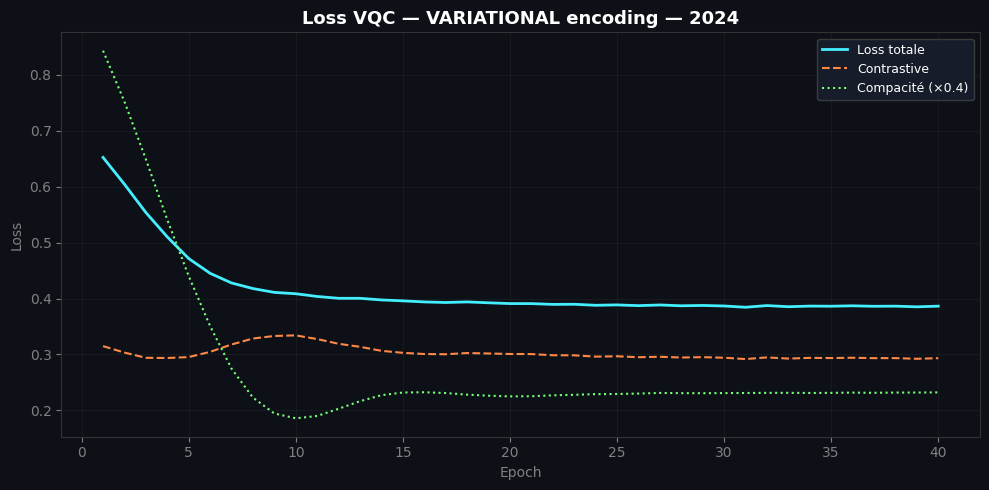

   📈 Courbe loss → /kaggle/working/quantum_clustering/loss_curve_variational_2024.png

✅ TOUS LES VQC ENTRAÎNÉS
  variational | 2024 | loss_init=0.651998 → loss_final=0.386350 | Δ=+0.265648


In [22]:
# ============================================================
# CELLULE 8 — Entraînement VQC avec checkpoints
# ============================================================
# Pour chaque combinaison (encoding × année) :
#   1. Vérifie si un checkpoint existe → reprise automatique
#   2. Entraîne le VQC avec la loss hybride
#   3. Log clair : loss totale / contrastive / compacité par epoch
#   4. Checkpoint toutes les 5 epochs + checkpoint final
#   5. Courbe de loss sauvegardée en PNG
#
# Structure checkpoint :
#   {
#     model_state_dict : poids VQC + projection
#     optimizer_state  : état Adam (pour reprise exacte)
#     epoch            : dernière epoch complète
#     loss_history     : [loss_total, l_contr, l_compact] par epoch
#     encoding         : str
#     year             : int
#     config           : hyperparamètres
#   }

trained_models = {}   # { (enc, year): QuantumEmbeddingModel }
loss_histories = {}   # { (enc, year): [(total, contr, compact)] par epoch }


def get_ckpt_path_for_load(enc, year):
    """Cherche le checkpoint à CHARGER — working d'abord, puis input (session précédente)."""
    fname = f"vqc_{enc}_{year}.pt"
    working_path = os.path.join(CKPT_DIR, fname)
    if os.path.exists(working_path):
        return working_path
    if CKPT_DIR_INPUT:
        input_path = os.path.join(CKPT_DIR_INPUT, fname)
        if os.path.exists(input_path):
            return input_path
    return None

def get_ckpt_path_for_save(enc, year):
    """Toujours sauvegarder dans /kaggle/working/ (writeable)."""
    return os.path.join(CKPT_DIR, f"vqc_{enc}_{year}.pt")


def save_checkpoint(model, optimizer, epoch, history, enc, year):
    torch.save({
        "model_state_dict" : model.state_dict(),
        "optimizer_state"  : optimizer.state_dict(),
        "epoch"            : epoch,
        "loss_history"     : history,
        "encoding"         : enc,
        "year"             : year,
        "config"           : {
            "n_qubits" : N_QUBITS, "n_layers"  : N_LAYERS,
            "pca_dim"  : PCA_DIM,  "n_epochs"  : N_EPOCHS_VQC,
            "lr"       : LR_VQC,   "batch_size": BATCH_SIZE_Q,
            "k_nn"     : K_NN,     "lambda"    : LAMBDA_COMPACT,
        },
    }, get_ckpt_path_for_save(enc, year))


def load_checkpoint_if_exists(model, optimizer, enc, year):
    """
    Charge le checkpoint si disponible.
    Retourne (start_epoch, loss_history).
    """
    path = get_ckpt_path_for_load(enc, year)
    if path is None:
        print(f"   ℹ️  Aucun checkpoint — démarrage from scratch")
        return 0, []
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    print(f"   ♻️  Checkpoint chargé : {path}")
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    start_ep = ckpt["epoch"] + 1
    history  = ckpt["loss_history"]
    print(f"   ♻️  Checkpoint trouvé → reprise depuis epoch {start_ep}")
    return start_ep, history


def plot_loss_curve(history, enc, year):
    """Sauvegarde la courbe de loss en PNG."""
    if not history:
        return
    totals   = [h[0] for h in history]
    contrs   = [h[1] for h in history]
    compacts = [h[2] for h in history]
    epochs   = list(range(1, len(history) + 1))

    fig, ax = plt.subplots(figsize=(10, 5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.plot(epochs, totals,   color="#4ef",  linewidth=2,   label="Loss totale")
    ax.plot(epochs, contrs,   color="#f84",  linewidth=1.5, linestyle="--", label="Contrastive")
    ax.plot(epochs, compacts, color="#7f7",  linewidth=1.5, linestyle=":",  label=f"Compacité (×{LAMBDA_COMPACT})")
    ax.set_title(f"Loss VQC — {enc.upper()} encoding — {year}",
                 color="white", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch", color="gray", fontsize=10)
    ax.set_ylabel("Loss",  color="gray", fontsize=10)
    ax.tick_params(colors="gray")
    for sp in ax.spines.values(): sp.set_color("#333")
    ax.legend(facecolor="#1a2030", edgecolor="#444", labelcolor="white", fontsize=9)
    ax.grid(alpha=0.15, color="#555")
    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"loss_curve_{enc}_{year}.png")
    plt.savefig(path, dpi=120, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    plt.close(fig)
    print(f"   📈 Courbe loss → {path}")


def train_one_vqc(enc, year):
    """
    Entraîne (ou reprend) le VQC pour (enc, year).
    Affiche les logs par epoch.
    Retourne le modèle entraîné.
    """
    print(f"\n{'='*65}")
    print(f"  ⚛️  ENTRAÎNEMENT VQC | encoding={enc.upper()} | année={year}")
    print(f"{'='*65}")

    pp, pn, s_idx = knn_cache[year]
    emb_pca       = pca_embeddings[year]   # (N, 8)
    emb_train     = emb_pca[s_idx]         # (S, 8) sous-échantillon
    X_train       = torch.tensor(emb_train, dtype=torch.float32)
    S             = len(s_idx)

    # Conversion paires en tenseurs
    PP = torch.tensor(pp, dtype=torch.long)
    PN = torch.tensor(pn, dtype=torch.long)

    # Modèle + optimiseur
    model     = QuantumEmbeddingModel(enc)
    optimizer = Adam(model.parameters(), lr=LR_VQC, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS_VQC, eta_min=1e-5)

    # Reprise depuis checkpoint si disponible
    start_epoch, history = load_checkpoint_if_exists(model, optimizer, enc, year)

    if start_epoch >= N_EPOCHS_VQC:
        print(f"   ✅ Déjà entraîné ({N_EPOCHS_VQC} epochs) — chargement direct")
        return model, history

    n_batches = max(1, S // BATCH_SIZE_Q)
    total_params = sum(p.numel() for p in model.parameters())

    print(f"   Encoding      : {enc}")
    print(f"   Année         : {year}")
    print(f"   Train samples : {S:,}")
    print(f"   Batch size    : {BATCH_SIZE_Q}  → {n_batches} batches/epoch")
    print(f"   Epochs        : {start_epoch} → {N_EPOCHS_VQC}")
    print(f"   Total params  : {total_params}")
    print(f"   Paires pos    : {len(pp):,}  | paires neg : {len(pn):,}")
    print(f"   Checkpoint    : {get_ckpt_path_for_save(enc, year)}")
    print()
    print(f"   {'Epoch':>6}  {'Loss Total':>12}  {'Contrastive':>13}  {'Compacité':>11}  {'LR':>10}  {'Temps':>7}")
    print(f"   {'-'*6}  {'-'*12}  {'-'*13}  {'-'*11}  {'-'*10}  {'-'*7}")

    t_start = time.time()

    for epoch in range(start_epoch, N_EPOCHS_VQC):
        model.train()
        epoch_total   = 0.0
        epoch_contr   = 0.0
        epoch_compact = 0.0
        t_ep = time.time()

        perm = torch.randperm(S)

        for b in range(n_batches):
            i0    = b * BATCH_SIZE_Q
            i1    = min(i0 + BATCH_SIZE_Q, S)
            idx_b = perm[i0:i1]
            x_b   = X_train[idx_b]

            # Filtrer et remapper les paires dans le batch courant
            idx_set = set(idx_b.tolist())
            idx_map = {g: l for l, g in enumerate(idx_b.tolist())}

            def remap(pairs_t):
                keep = [(pairs_t[k,0].item() in idx_set and
                         pairs_t[k,1].item() in idx_set)
                        for k in range(len(pairs_t))]
                if not any(keep):
                    return torch.zeros(0, 2, dtype=torch.long)
                f = pairs_t[keep]
                return torch.tensor([[idx_map[f[k,0].item()],
                                      idx_map[f[k,1].item()]]
                                     for k in range(len(f))], dtype=torch.long)

            pp_b = remap(PP)
            pn_b = remap(PN)

            optimizer.zero_grad()
            z_b = model(x_b)
            loss, lc, lk = hybrid_loss(z_b, pp_b, pn_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_total   += loss.item()
            epoch_contr   += lc
            epoch_compact += lk

        scheduler.step()

        avg_total   = epoch_total   / n_batches
        avg_contr   = epoch_contr   / n_batches
        avg_compact = epoch_compact / n_batches
        current_lr  = optimizer.param_groups[0]['lr']
        t_ep_sec    = time.time() - t_ep

        history.append((avg_total, avg_contr, avg_compact))

        # ── Log epoch ────────────────────────────────────────
        print(f"   {epoch+1:>6}  {avg_total:>12.6f}  {avg_contr:>13.6f}  "
              f"{avg_compact:>11.6f}  {current_lr:>10.2e}  {t_ep_sec:>6.1f}s")

        # ── Checkpoint toutes les 5 epochs ───────────────────
        if (epoch + 1) % 5 == 0 or (epoch + 1) == N_EPOCHS_VQC:
            save_checkpoint(model, optimizer, epoch, history, enc, year)
            elapsed = time.time() - t_start
            remaining_ep = N_EPOCHS_VQC - epoch - 1
            eta = (elapsed / (epoch - start_epoch + 1)) * remaining_ep
            print(f"   {'':6}  💾 Checkpoint sauvegardé "
                  f"| elapsed={elapsed/60:.1f}min "
                  f"| ETA≈{eta/60:.0f}min")

    total_time = time.time() - t_start
    final_loss = history[-1][0] if history else 0
    print(f"\n   ✅ ENTRAÎNEMENT TERMINÉ")
    print(f"   Temps total : {total_time/60:.1f} min")
    print(f"   Loss finale : {final_loss:.6f}")
    print(f"   Δ loss      : {history[0][0] - final_loss:.6f} "
          f"({'↓ amélioration' if history[0][0] > final_loss else '↑ dégradation'})")

    # Courbe de loss
    plot_loss_curve(history, enc, year)

    return model, history


# ── Boucle principale : tous les encodings × toutes les années ─
print("\n" + "#" * 65)
print("  ⚛️  LANCEMENT ENTRAÎNEMENT VQC")
print(f"  {len(ENCODINGS)} encodings × 2 années = {len(ENCODINGS)*2} modèles")
print("#" * 65)

for year in [2024]:  # 2024 uniquement
    print(f"\n{'#'*65}")
    print(f"  ANNÉE {year}")
    print(f"{'#'*65}")
    for enc in ENCODINGS:
        model, hist = train_one_vqc(enc, year)
        trained_models[(enc, year)] = model
        loss_histories[(enc, year)] = hist
        gc.collect()

print("\n" + "=" * 65)
print("✅ TOUS LES VQC ENTRAÎNÉS")
print("=" * 65)
for key in trained_models:
    h = loss_histories[key]
    if h:
        print(f"  {key[0]:>10} | {key[1]} | loss_init={h[0][0]:.6f} → "
              f"loss_final={h[-1][0]:.6f} | "
              f"Δ={h[0][0]-h[-1][0]:+.6f}")

In [23]:
# ============================================================
# CELLULE 9 — Inférence : génération des embeddings quantiques
# ============================================================
# Stratégie pour gérer les 246k auteurs (2024) sans OOM :
#   1. Inférence VQC sur INFER_SUBSAMPLE=30k points (rapide)
#   2. Pour les N-30k points restants :
#      → k-NN dans l'espace PCA original (8D, ultra-rapide)
#      → Propagation : embedding_i = moyenne pondérée des voisins quantiques
#   Cette approche est cohérente car le VQC est une transformation lisse :
#   les points proches en PCA ont des transformations proches.
#
# Sauvegarde : qemb_{enc}_{year}.pt
#   {
#     "embeddings" : Tensor (N, N_QUBITS) — tous les auteurs
#     "node_ids"   : Tensor (N,)
#     "encoding"   : str
#     "year"       : int
#     "method"     : "vqc_direct" ou "knn_propagation"
#   }

quantum_embeddings = {}   # { (enc, year): np.array (N, N_QUBITS) }


def infer_vqc_on_subset(model, emb_pca_np, indices, batch_size=BATCH_SIZE_Q):
    """
    Inférence VQC sur un sous-ensemble d'indices.
    Retourne (S, N_QUBITS) numpy.
    """
    model.eval()
    emb_sub = emb_pca_np[indices]   # (S, 8)
    S       = len(indices)
    results = []

    with torch.no_grad():
        for start in range(0, S, batch_size):
            end = min(start + batch_size, S)
            x_b = torch.tensor(emb_sub[start:end], dtype=torch.float32)
            z_b = model(x_b)   # (B, N_QUBITS)
            results.append(z_b.numpy())
            if start % 5000 == 0 and start > 0:
                print(f"     Inférence VQC : {start:,}/{S:,} "
                      f"({100*start/S:.0f}%)")

    return np.concatenate(results, axis=0)   # (S, N_QUBITS)


def propagate_knn(z_anchor, emb_anchor, emb_all, k=5):
    """
    Propage les embeddings quantiques des anchor points aux autres
    via k-NN dans l'espace PCA.

    z_anchor   : (S, N_QUBITS) embeddings quantiques connus (sur infer_indices)
    emb_anchor : (S, 8)        embeddings PCA des anchor points
    emb_all    : (N, 8)        tous les embeddings PCA
    → retourne (N, N_QUBITS)   embeddings quantiques pour tous les points
    """
    N = emb_all.shape[0]
    S = len(z_anchor)

    print(f"   Propagation k-NN : {S:,} anchors → {N:,} points (k={k})...")
    t0 = time.time()

    nn_model = NearestNeighbors(n_neighbors=k, metric='cosine', n_jobs=-1)
    nn_model.fit(emb_anchor)
    dists, indices = nn_model.kneighbors(emb_all)   # (N, k)

    # Pondération inverse de la distance cosine
    weights = 1.0 / (dists + 1e-9)          # (N, k)
    weights = weights / weights.sum(axis=1, keepdims=True)   # normalisation

    # Moyenne pondérée des embeddings quantiques des voisins
    z_propagated = np.einsum('nk,nkd->nd', weights, z_anchor[indices])  # (N, D)
    # L2-normalisation finale
    norms        = np.linalg.norm(z_propagated, axis=1, keepdims=True) + 1e-9
    z_propagated = z_propagated / norms

    print(f"   ✅ Propagation terminée en {time.time()-t0:.1f}s")
    return z_propagated.astype(np.float32)


print("=" * 65)
print("⚛️  INFÉRENCE — GÉNÉRATION EMBEDDINGS QUANTIQUES")
print("=" * 65)
print(f"  Stratégie : VQC direct sur {INFER_SUBSAMPLE:,} points")
print(f"             + propagation k-NN pour les points restants")
print()

for year in [2024]:  # 2024 uniquement
    emb_pca = pca_embeddings[year]   # (N, 8)
    N       = emb_pca.shape[0]

    # Indices d'inférence directe
    if N > INFER_SUBSAMPLE:
        rng      = np.random.default_rng(SEED + 10)
        infer_idx = rng.choice(N, INFER_SUBSAMPLE, replace=False)
    else:
        infer_idx = np.arange(N)

    print(f"\n  ── ANNÉE {year}  ({N:,} auteurs) ──")
    print(f"  Inférence directe VQC : {len(infer_idx):,} points")
    print(f"  Propagation k-NN      : {N - len(infer_idx):,} points")

    for enc in ENCODINGS:
        print(f"\n  Encoding : {enc.upper()}")
        model = trained_models[(enc, year)]

        # ── Étape 1 : Inférence VQC directe ─────────────────
        print(f"  [1/3] Inférence VQC sur {len(infer_idx):,} anchors...")
        t0       = time.time()
        z_anchor = infer_vqc_on_subset(model, emb_pca, infer_idx)
        print(f"        ✅ {len(infer_idx):,} embeddings quantiques en {time.time()-t0:.1f}s")
        print(f"        shape={z_anchor.shape}  "
              f"norm_mean={np.linalg.norm(z_anchor, axis=1).mean():.4f}")

        # ── Étape 2 : Propagation k-NN ───────────────────────
        print(f"  [2/3] Propagation k-NN → {N:,} auteurs...")
        z_all = propagate_knn(
            z_anchor   = z_anchor,
            emb_anchor = emb_pca[infer_idx],
            emb_all    = emb_pca,
            k          = 5,
        )   # (N, N_QUBITS)

        quantum_embeddings[(enc, year)] = z_all

        # ── Étape 3 : Sauvegarde ─────────────────────────────
        print(f"  [3/3] Sauvegarde...")
        out_path = os.path.join(OUTPUT_DIR, f"qemb_{enc}_{year}.pt")
        torch.save({
            "embeddings"  : torch.tensor(z_all),
            "node_ids"    : torch.tensor(node_ids_dict[year]),
            "encoding"    : enc,
            "year"        : year,
            "n_qubits"    : N_QUBITS,
            "shape"       : z_all.shape,
            "infer_method": "vqc_direct+knn_propagation",
        }, out_path)

        print(f"        ✅ shape={z_all.shape}  "
              f"norm_mean={np.linalg.norm(z_all, axis=1).mean():.4f}")
        print(f"        💾 → {out_path}")
        gc.collect()

print("\n" + "=" * 65)
print("✅ Tous les embeddings quantiques générés !")
print("=" * 65)

⚛️  INFÉRENCE — GÉNÉRATION EMBEDDINGS QUANTIQUES
  Stratégie : VQC direct sur 30,000 points
             + propagation k-NN pour les points restants


  ── ANNÉE 2024  (246,113 auteurs) ──
  Inférence directe VQC : 30,000 points
  Propagation k-NN      : 216,113 points

  Encoding : VARIATIONAL
  [1/3] Inférence VQC sur 30,000 anchors...
        ✅ 30,000 embeddings quantiques en 302.9s
        shape=(30000, 8)  norm_mean=1.0000
  [2/3] Propagation k-NN → 246,113 auteurs...
   Propagation k-NN : 30,000 anchors → 246,113 points (k=5)...
   ✅ Propagation terminée en 112.8s
  [3/3] Sauvegarde...
        ✅ shape=(246113, 8)  norm_mean=1.0000
        💾 → /kaggle/working/quantum_clustering/qemb_variational_2024.pt

✅ Tous les embeddings quantiques générés !



#################################################################
  🔬 LANCEMENT CLUSTERING QUANTIQUE
  1 encodings × 2 années = 2 runs
#################################################################

  🔬 CLUSTERING QUANTIQUE | encoding=VARIATIONAL | année=2024
  Embeddings quantiques : shape=(246113, 8)

  [1/3] UMAP  (n_neighbors=15, metric=cosine, min_dist=0.05)
       ✅ UMAP terminé en 3909.0s  → shape=(246113, 2)
  [2/3] HDBSCAN  (min_cluster_size=300, min_samples=30)
       ✅ HDBSCAN terminé en 15.4s
       → 13 clusters | bruit=6,122 (2.5%)
  [3/3] Calcul métriques...
       Silhouette       : -0.3154  (-0.6614 vs classic ❌ moins bien)
       Davies-Bouldin   : 0.7831   (+0.1521 vs classic ❌ moins bien)
       Calinski-Harabasz: 4718.5
       Bruit            : 2.5%  (-26.5% vs classic ✅ mieux)
       💾 NPZ  → /kaggle/working/quantum_clustering/clustering/qcluster_variational_2024.npz
       💾 JSON → /kaggle/working/quantum_clustering/clustering/qmetrics_variational_2024.json


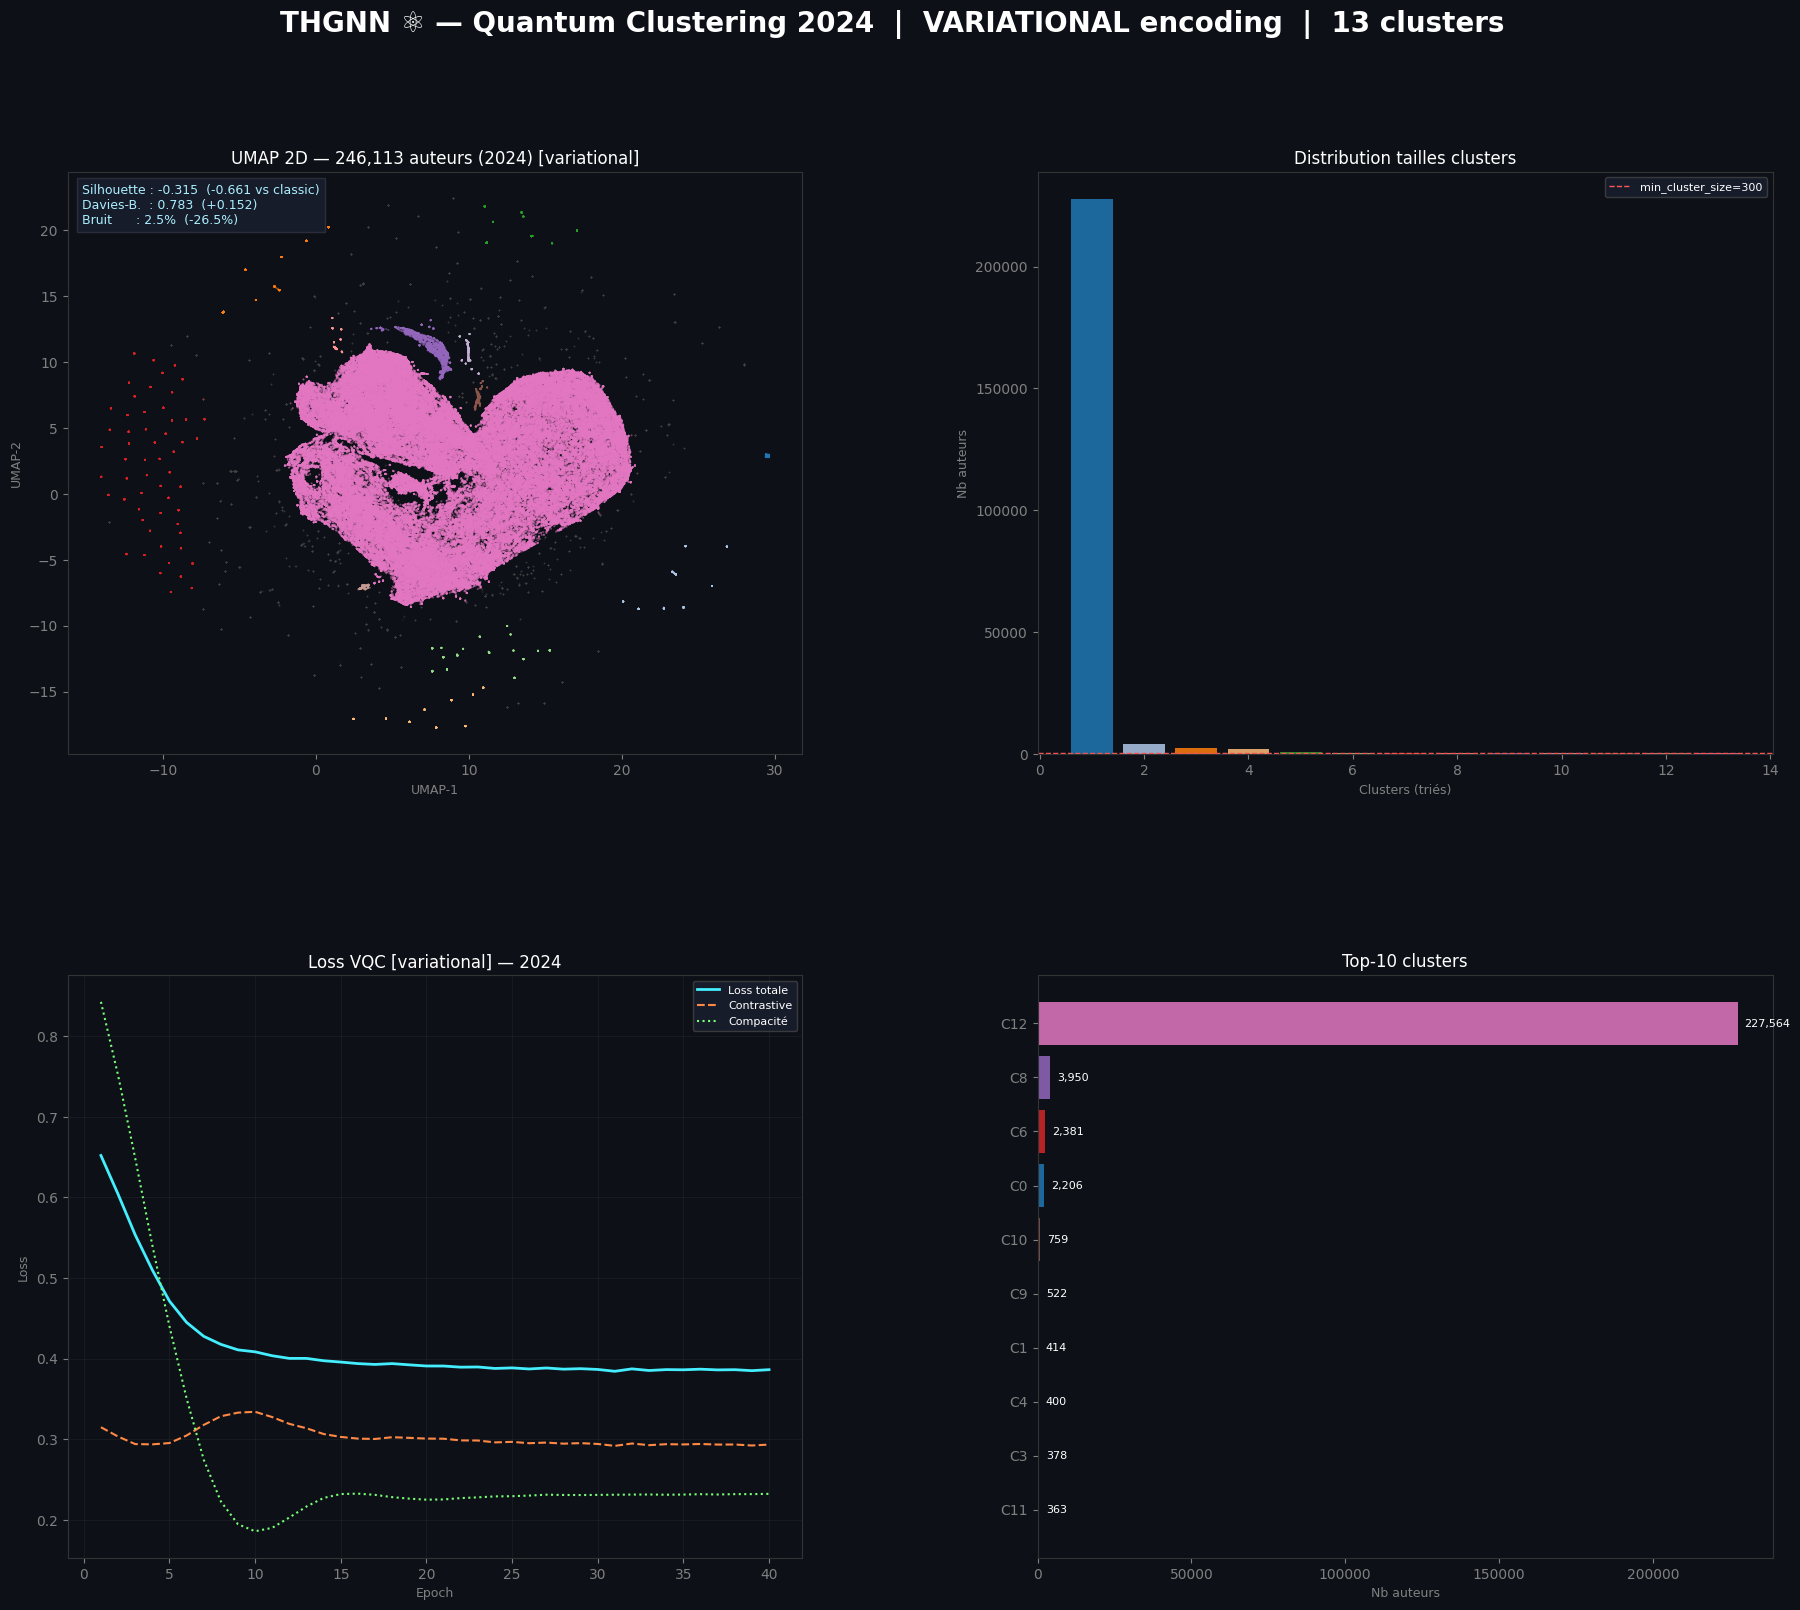

   🖼️  Figure → /kaggle/working/quantum_clustering/clustering/qfig_variational_2024.png

✅ CLUSTERING QUANTIQUE TERMINÉ POUR TOUS LES ENCODINGS


In [24]:
# ============================================================
# CELLULE 10 — Clustering quantique (UMAP + HDBSCAN)
# ============================================================
# ⚠️  COMPARAISON ÉQUITABLE : hyperparams HDBSCAN et UMAP strictement
#     identiques à la baseline classique.
#
# Outputs par (enc, year) dans OUTPUT_DIR/clustering/ :
#   qcluster_{enc}_{year}.npz   ← z_2d (N,2) + labels (N,) + node_ids (N,)
#   qmetrics_{enc}_{year}.json  ← métriques complètes
#   qfig_{enc}_{year}.png       ← visualisation 4 panneaux

all_quantum_metrics = {}   # { (enc, year): dict métriques }


def make_palette(n):
    base = plt.cm.get_cmap("tab20", max(n, 20))
    return [base(i % 20) for i in range(n)]


def plot_quantum_clustering(enc, year, z_2d, labels, n_clusters,
                             noise_pct, sil, db, ch):
    """Visualisation 4 panneaux — identique au style classique pour comparaison directe."""
    palette = make_palette(n_clusters)
    counts  = Counter(labels[labels != -1].tolist())
    N       = len(labels)

    fig = plt.figure(figsize=(22, 18), facecolor="#0d1117")
    fig.suptitle(
        f"THGNN ⚛ — Quantum Clustering {year}  |  "
        f"{enc.upper()} encoding  |  {n_clusters} clusters",
        fontsize=20, color="white", fontweight="bold", y=0.97
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    # ── A : UMAP scatter ─────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.set_facecolor("#0d1117")
    nm = labels == -1
    vm = ~nm
    ax1.scatter(z_2d[nm,0], z_2d[nm,1], c="#444", s=1.5,
                alpha=0.25, linewidths=0, rasterized=True)
    if vm.sum() > 0:
        ax1.scatter(z_2d[vm,0], z_2d[vm,1],
                    c=[palette[int(l) % len(palette)] for l in labels[vm]],
                    s=2, alpha=0.5, linewidths=0, rasterized=True)
    ax1.set_title(f"UMAP 2D — {N:,} auteurs ({year}) [{enc}]",
                  color="white", fontsize=12)
    ax1.tick_params(colors="gray")
    for sp in ax1.spines.values(): sp.set_color("#333")
    ax1.set_xlabel("UMAP-1", color="gray", fontsize=9)
    ax1.set_ylabel("UMAP-2", color="gray", fontsize=9)
    b = BASELINE[year]
    d_sil = sil - b['silhouette']
    d_db  = db  - b['davies_bouldin']
    d_n   = noise_pct - b['noise_pct']
    ax1.text(0.02, 0.98,
             f"Silhouette : {sil:.3f}  ({d_sil:+.3f} vs classic)\n"
             f"Davies-B.  : {db:.3f}  ({d_db:+.3f})\n"
             f"Bruit      : {noise_pct:.1f}%  ({d_n:+.1f}%)",
             transform=ax1.transAxes, fontsize=9, color="#aef", va="top",
             bbox=dict(facecolor="#1a2030", alpha=0.8, edgecolor="#334"))

    # ── B : Distribution tailles clusters ────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_facecolor("#0d1117")
    sizes = sorted(counts.values(), reverse=True)
    ax2.bar(range(1, len(sizes)+1),
            sizes,
            color=[palette[i % len(palette)] for i in range(len(sizes))],
            alpha=0.85, width=0.8)
    ax2.axhline(MIN_CLUSTER_SIZE, color="#f55", linestyle="--", linewidth=1,
                label=f"min_cluster_size={MIN_CLUSTER_SIZE}")
    ax2.set_title("Distribution tailles clusters", color="white", fontsize=12)
    ax2.set_xlabel("Clusters (triés)", color="gray", fontsize=9)
    ax2.set_ylabel("Nb auteurs", color="gray", fontsize=9)
    ax2.tick_params(colors="gray")
    for sp in ax2.spines.values(): sp.set_color("#333")
    ax2.legend(facecolor="#1a2030", edgecolor="#444", labelcolor="white", fontsize=8)

    # ── C : Courbe de loss VQC ───────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.set_facecolor("#0d1117")
    hist = loss_histories.get((enc, year), [])
    if hist:
        ep      = list(range(1, len(hist)+1))
        totals  = [h[0] for h in hist]
        contrs  = [h[1] for h in hist]
        compacs = [h[2] for h in hist]
        ax3.plot(ep, totals,  color="#4ef",  lw=2,   label="Loss totale")
        ax3.plot(ep, contrs,  color="#f84",  lw=1.5, linestyle="--", label="Contrastive")
        ax3.plot(ep, compacs, color="#7f7",  lw=1.5, linestyle=":",  label="Compacité")
        ax3.set_title(f"Loss VQC [{enc}] — {year}", color="white", fontsize=12)
        ax3.set_xlabel("Epoch", color="gray", fontsize=9)
        ax3.set_ylabel("Loss",  color="gray", fontsize=9)
        ax3.tick_params(colors="gray")
        for sp in ax3.spines.values(): sp.set_color("#333")
        ax3.legend(facecolor="#1a2030", edgecolor="#444",
                   labelcolor="white", fontsize=8)
        ax3.grid(alpha=0.15, color="#555")

    # ── D : Top-10 clusters ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.set_facecolor("#0d1117")
    top10   = counts.most_common(10)
    cids    = [f"C{c}" for c, _ in top10][::-1]
    csizes  = [s for _, s in top10][::-1]
    bcolors = [palette[int(c) % len(palette)] for c, _ in reversed(top10)]
    bars = ax4.barh(cids, csizes, color=bcolors, alpha=0.85)
    for bar, val in zip(bars, csizes):
        ax4.text(bar.get_width() + max(csizes)*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va="center", ha="left",
                 color="white", fontsize=8)
    ax4.set_title("Top-10 clusters", color="white", fontsize=12)
    ax4.set_xlabel("Nb auteurs", color="gray", fontsize=9)
    ax4.tick_params(colors="gray")
    for sp in ax4.spines.values(): sp.set_color("#333")

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig_path = os.path.join(CLUSTER_OUT, f"qfig_{enc}_{year}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    plt.close(fig)
    print(f"   🖼️  Figure → {fig_path}")


def run_clustering(enc, year):
    """UMAP → HDBSCAN → métriques → visualisation pour (enc, year)."""
    print(f"\n{'='*65}")
    print(f"  🔬 CLUSTERING QUANTIQUE | encoding={enc.upper()} | année={year}")
    print(f"{'='*65}")

    z_q      = quantum_embeddings[(enc, year)]   # (N, N_QUBITS)
    node_ids = node_ids_dict[year]
    N        = z_q.shape[0]

    print(f"  Embeddings quantiques : shape={z_q.shape}")
    print()

    # ── UMAP ────────────────────────────────────────────────
    print(f"  [1/3] UMAP  (n_neighbors={UMAP_N_NEIGHBORS}, "
          f"metric={UMAP_METRIC}, min_dist={UMAP_MIN_DIST})")
    t0 = time.time()
    reducer = umap.UMAP(
        n_neighbors  = UMAP_N_NEIGHBORS,
        n_components = 2,
        min_dist     = UMAP_MIN_DIST,
        metric       = UMAP_METRIC,
        random_state = SEED,
        low_memory   = True,
        verbose      = False,
    )
    z_2d = reducer.fit_transform(z_q)
    print(f"       ✅ UMAP terminé en {time.time()-t0:.1f}s  → shape={z_2d.shape}")

    # ── HDBSCAN ─────────────────────────────────────────────
    print(f"  [2/3] HDBSCAN  (min_cluster_size={MIN_CLUSTER_SIZE}, "
          f"min_samples={MIN_SAMPLES})")
    t0        = time.time()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size         = MIN_CLUSTER_SIZE,
        min_samples              = MIN_SAMPLES,
        metric                   = "euclidean",
        cluster_selection_method = "eom",
        prediction_data          = True,
    )
    labels    = clusterer.fit_predict(z_2d)
    n_cl      = int(len(set(labels)) - (1 if -1 in labels else 0))
    noise     = int((labels == -1).sum())
    noise_pct = 100.0 * noise / N
    print(f"       ✅ HDBSCAN terminé en {time.time()-t0:.1f}s")
    print(f"       → {n_cl} clusters | bruit={noise:,} ({noise_pct:.1f}%)")

    # ── Métriques ────────────────────────────────────────────
    print(f"  [3/3] Calcul métriques...")
    mask = labels != -1
    if mask.sum() > 1 and n_cl > 1:
        ss = min(10_000, int(mask.sum()))
        sil = silhouette_score(z_2d[mask], labels[mask], sample_size=ss)
        db  = davies_bouldin_score(z_2d[mask], labels[mask])
        ch  = calinski_harabasz_score(z_2d[mask], labels[mask])
    else:
        sil, db, ch = 0.0, 0.0, 0.0

    b     = BASELINE[year]
    d_sil = sil - b['silhouette']
    d_db  = db  - b['davies_bouldin']
    d_n   = noise_pct - b['noise_pct']

    print(f"       Silhouette       : {sil:.4f}  ({d_sil:+.4f} vs classic "
          f"{'✅ mieux' if d_sil > 0 else '❌ moins bien'})")
    print(f"       Davies-Bouldin   : {db:.4f}   ({d_db:+.4f} vs classic "
          f"{'✅ mieux' if d_db < 0 else '❌ moins bien'})")
    print(f"       Calinski-Harabasz: {ch:.1f}")
    print(f"       Bruit            : {noise_pct:.1f}%  ({d_n:+.1f}% vs classic "
          f"{'✅ mieux' if d_n < 0 else '❌ moins bien'})")

    # ── Sauvegarde NPZ ────────────────────────────────────────
    npz_path = os.path.join(CLUSTER_OUT, f"qcluster_{enc}_{year}.npz")
    np.savez_compressed(npz_path,
                        z_2d=z_2d, labels=labels,
                        node_ids=node_ids.astype(np.int64))

    # ── JSON métriques — tous les float32 castés en float Python ──
    metrics = {
        "encoding"          : enc,
        "year"              : year,
        "n_clusters"        : int(n_cl),
        "noise"             : int(noise),
        "noise_pct"         : float(round(float(noise_pct), 2)),
        "silhouette"        : float(sil),
        "davies_bouldin"    : float(db),
        "calinski_harabasz" : float(ch),
        "total_authors"     : int(N),
        "delta_vs_classic"  : {
            "silhouette"     : float(round(float(d_sil), 4)),
            "davies_bouldin" : float(round(float(d_db),  4)),
            "noise_pct"      : float(round(float(d_n),   2)),
        },
        "top10_clusters" : [
            {"cluster_id": int(c), "size": int(s)}
            for c, s in Counter(labels[labels!=-1].tolist()).most_common(10)
        ],
    }
    json_path = os.path.join(CLUSTER_OUT, f"qmetrics_{enc}_{year}.json")
    with open(json_path, "w") as f:
        json.dump(metrics, f, indent=2)

    all_quantum_metrics[(enc, year)] = metrics
    print(f"       💾 NPZ  → {npz_path}")
    print(f"       💾 JSON → {json_path}")

    # ── Visualisation ─────────────────────────────────────────
    plot_quantum_clustering(enc, year, z_2d, labels, n_cl, noise_pct, sil, db, ch)

    del z_2d, labels, clusterer, reducer
    gc.collect()
    return metrics


# ── Boucle clustering ─────────────────────────────────────────
print("\n" + "#" * 65)
print("  🔬 LANCEMENT CLUSTERING QUANTIQUE")
print(f"  {len(ENCODINGS)} encodings × 2 années = {len(ENCODINGS)*2} runs")
print("#" * 65)

for year in [2024]:  # 2024 uniquement
    for enc in ENCODINGS:
        run_clustering(enc, year)

print("\n" + "=" * 65)
print("✅ CLUSTERING QUANTIQUE TERMINÉ POUR TOUS LES ENCODINGS")
print("=" * 65)


📊 COMPARAISON FINALE — CLASSIQUE vs QUANTIQUE (ANGLE / PHASE / AMPLITUDE)

  ───────────────────────────────────────────────────────────────────────────
  ANNÉE 2024
  ───────────────────────────────────────────────────────────────────────────
  Méthode                  Clusters   Silhouette     DB (↓)           CH   Bruit%
  ──────────────────────  ──────────  ──────────  ────────  ──────────  ──────
  THGNN Classique               107       0.3460     0.6310      61670.0    29.0%
    VQC [variational]            13    -0.3154❌   0.7831❌       4718.5    2.5%✅


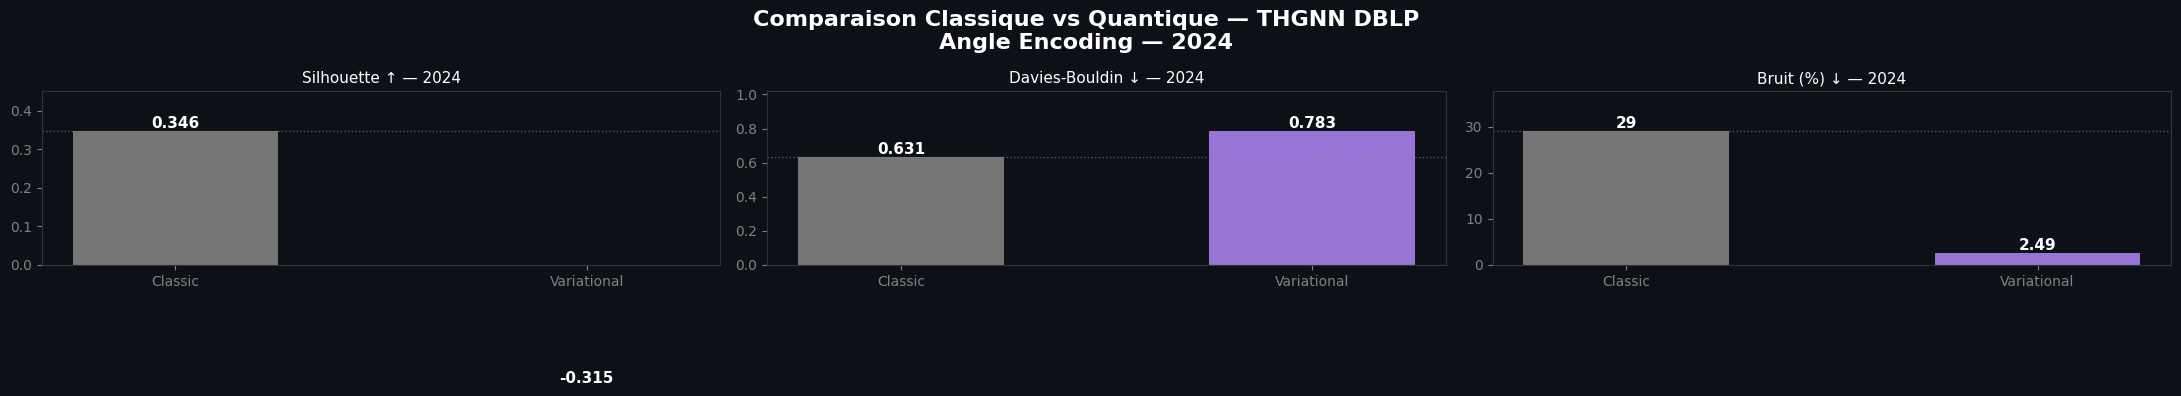


🖼️  Graphe comparaison → /kaggle/working/quantum_clustering/quantum_vs_classic_comparison.png
💾 Résumé JSON → /kaggle/working/quantum_clustering/quantum_summary.json

✅ PIPELINE QUANTIQUE TERMINÉ

📂 Fichiers dans /kaggle/working/quantum_clustering/
   checkpoints/
      vqc_variational_2024.pt         ← poids VQC + historique loss
   clustering/
      qcluster_variational_2024.npz    ← z_2d + labels + node_ids
      qmetrics_variational_2024.json   ← métriques + delta_vs_classic
      qfig_variational_2024.png        ← figure 4 panneaux
   loss_curve_variational_2024.png   ← courbe loss VQC
   qemb_variational_2024.pt          ← embeddings quantiques (N, 8)
   quantum_vs_classic_comparison.png
   quantum_summary.json


In [25]:
# ============================================================
# CELLULE 11 — Comparaison finale : Classique vs Quantique
# ============================================================
# Tableau terminal récapitulatif + graphes côte à côte.
# Analyse quantitative et qualitative.

print("\n" + "="*80)
print("📊 COMPARAISON FINALE — CLASSIQUE vs QUANTIQUE (ANGLE / PHASE / AMPLITUDE)")
print("="*80)

# ── Tableau terminal ──────────────────────────────────────────
for year in [2024]:  # 2024 uniquement
    b = BASELINE[year]
    print(f"\n  {'─'*75}")
    print(f"  ANNÉE {year}")
    print(f"  {'─'*75}")
    print(f"  {'Méthode':<22} {'Clusters':>10} {'Silhouette':>12} "
          f"{'DB (↓)':>10} {'CH':>12} {'Bruit%':>8}")
    print(f"  {'─'*22}  {'─'*10}  {'─'*10}  {'─'*8}  {'─'*10}  {'─'*6}")

    # Classique
    print(f"  {'THGNN Classique':<22} {b['n_clusters']:>10} "
          f"{b['silhouette']:>12.4f} {b['davies_bouldin']:>10.4f} "
          f"{b['calinski_harabasz']:>12.1f} {b['noise_pct']:>7.1f}%")

    # Quantiques
    for enc in ENCODINGS:
        m = all_quantum_metrics.get((enc, year), {})
        if not m:
            continue
        d = m['delta_vs_classic']
        sil_sym = '✅' if d['silhouette'] > 0     else '❌'
        db_sym  = '✅' if d['davies_bouldin'] < 0 else '❌'
        n_sym   = '✅' if d['noise_pct'] < 0      else '❌'
        label   = f"  VQC [{enc}]"
        print(f"  {label:<22} {m['n_clusters']:>10} "
              f"{m['silhouette']:>10.4f}{sil_sym} "
              f"{m['davies_bouldin']:>8.4f}{db_sym} "
              f"{m['calinski_harabasz']:>12.1f} "
              f"{m['noise_pct']:>6.1f}%{n_sym}")

# ── Graphes comparatifs ───────────────────────────────────────
metrics_keys   = ["silhouette", "davies_bouldin", "noise_pct"]
metrics_labels = ["Silhouette ↑", "Davies-Bouldin ↓", "Bruit (%) ↓"]
colors_enc     = {"classique": "#888", "variational": "#b088f9"}

# 1 seule année → 1 ligne → axes est un array 1D de 3 éléments
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor="#0d1117")
# axes est déjà 1D (shape (3,)) → axes[col] directement

fig.suptitle(
    "Comparaison Classique vs Quantique — THGNN DBLP\n"
    "Angle Encoding — 2024",
    color="white", fontsize=16, fontweight="bold"
)

year = 2024
b = BASELINE[year]
for col, (key, label) in enumerate(zip(metrics_keys, metrics_labels)):
    ax = axes[col]   # axes est 1D → pas de [row, col]
    ax.set_facecolor("#0d1117")

    methods = ["classique"] + ENCODINGS
    vals    = [b[key]] + [
        all_quantum_metrics.get((enc, year), {}).get(key, 0)
        for enc in ENCODINGS
    ]
    bar_cls = [colors_enc[m] for m in methods]
    xlbls   = ["Classic"] + [e.capitalize() for e in ENCODINGS]

    bars = ax.bar(xlbls, vals, color=bar_cls, alpha=0.85, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.025,
                f"{val:.3g}", ha="center", color="white",
                fontsize=11, fontweight="bold")

    ax.axhline(b[key], color="#888", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_title(f"{label} — {year}", color="white", fontsize=11)
    ax.tick_params(colors="gray")
    for sp in ax.spines.values(): sp.set_color("#333")
    ax.set_ylim(0, max(vals) * 1.3)

fig.tight_layout()
cmp_path = os.path.join(OUTPUT_DIR, "quantum_vs_classic_comparison.png")
plt.savefig(cmp_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
plt.close(fig)
print(f"\n🖼️  Graphe comparaison → {cmp_path}")

# ── JSON récapitulatif final ──────────────────────────────────
summary = {
    "description"    : "Quantum vs Classic clustering — THGNN DBLP",
    "vqc_config"     : {
        "n_qubits"      : N_QUBITS,
        "n_layers"      : N_LAYERS,
        "pca_dim"       : PCA_DIM,
        "n_epochs"      : N_EPOCHS_VQC,
        "lr"            : LR_VQC,
        "batch_size"    : BATCH_SIZE_Q,
        "k_nn"          : K_NN,
        "lambda_compact": LAMBDA_COMPACT,
        "train_sub"     : TRAIN_SUBSAMPLE,
        "infer_sub"     : INFER_SUBSAMPLE,
        "backend"       : BACKEND,
    },
    "hdbscan_params" : {
        "min_cluster_size" : MIN_CLUSTER_SIZE,
        "min_samples"      : MIN_SAMPLES,
        "umap_n_neighbors" : UMAP_N_NEIGHBORS,
        "umap_metric"      : UMAP_METRIC,
    },
    "baseline" : BASELINE,
    "quantum"  : {
        f"{enc}_{year}": all_quantum_metrics.get((enc, year), {})
        for enc in ENCODINGS for year in [2024]
    },
}
summary_path = os.path.join(OUTPUT_DIR, "quantum_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"💾 Résumé JSON → {summary_path}")

# ── Récapitulatif fichiers générés ───────────────────────────
print("\n" + "="*80)
print("✅ PIPELINE QUANTIQUE TERMINÉ")
print("="*80)
print(f"\n📂 Fichiers dans {OUTPUT_DIR}/")
print(f"   checkpoints/")
for enc in ENCODINGS:
    print(f"      vqc_{enc}_2024.pt         ← poids VQC + historique loss")
print(f"   clustering/")
for enc in ENCODINGS:
    print(f"      qcluster_{enc}_2024.npz    ← z_2d + labels + node_ids")
    print(f"      qmetrics_{enc}_2024.json   ← métriques + delta_vs_classic")
    print(f"      qfig_{enc}_2024.png        ← figure 4 panneaux")
for enc in ENCODINGS:
    print(f"   loss_curve_{enc}_2024.png   ← courbe loss VQC")
    print(f"   qemb_{enc}_2024.pt          ← embeddings quantiques (N, {N_QUBITS})")
print(f"   quantum_vs_classic_comparison.png")
print(f"   quantum_summary.json")
print("="*80)